# 02 · Capacity Model (WFM Step 2)

Convert demand + ticket-native handle time into **required agents per interval**, and compare against **available shift capacity** (UTC, follow-the-sun, minus time-off). Handle time is agent-occupied minutes (triage + per-reply), **not** elapsed resolution.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from collections import Counter
import nbutils
t = nbutils.load_tickets().merge(nbutils.load_metrics(), left_on='id', right_on='ticket_id')
t['handle_min'] = 6 + t['replies'].fillna(0) * 12   # triage + 12 min per agent reply
print('handle time (agent-min/ticket): median=%.0f  p90=%.0f' % (t['handle_min'].median(), t['handle_min'].quantile(.9)))

handle time (agent-min/ticket): median=30  p90=66


## Scale honesty: the sample is small vs. the roster
8k tickets/yr (~22/day) is a *fraction* of what a 45-agent operation handles. Raw occupancy is ~5%, so for meaningful staffing math we apply an explicit **volume scale factor** (sample→operation), derived to target ~80% average occupancy. A labeled PoC assumption.

In [2]:
UTIL = 0.8
WIN = nbutils.NOW - pd.Timedelta(days=56)          # recent window where shifts exist
r = t[t['created_at'] >= WIN].copy()
r['date'] = r['created_at'].dt.strftime('%Y-%m-%d'); r['hour'] = r['created_at'].dt.hour
sh = nbutils.load_shifts(); sh = sh[sh['date'] >= WIN].copy()
sh['s'] = pd.to_datetime(sh['start'], utc=True); sh['e'] = pd.to_datetime(sh['end'], utc=True)
sh['len'] = ((sh['e'] - sh['s']).dt.total_seconds() / 3600).round().astype(int)
sh['date'] = sh['date'].dt.strftime('%Y-%m-%d')
work_h = r.groupby('date')['handle_min'].sum() / 60
avail_h = sh.groupby('date')['len'].sum().mean()
S = round(0.8 * avail_h / work_h.mean(), 1)
print(f'unscaled workload {work_h.mean():.1f} agent-h/day vs {avail_h:.0f} available -> raw occ {100*work_h.mean()/avail_h:.1f}%')
print(f'volume scale factor S = {S}x')

unscaled workload 13.1 agent-h/day vs 254 available -> raw occ 5.2%
volume scale factor S = 15.5x


## Required vs. available agents, per (day, hour)
Required = scaled work-minutes in the hour / (60 · utilization). Available = agents on shift that UTC hour (spanning timezones).

In [3]:
req = r.groupby(['date','hour'])['handle_min'].sum().mul(S/(60*UTIL)).rename('required').reset_index()
avail = Counter()
for _, row in sh.iterrows():
    for k in range(row['len']):
        avail[(row['date'], (row['s'].hour + k) % 24)] += 1
avail_df = pd.DataFrame([{'date': d, 'hour': h, 'available': n} for (d, h), n in avail.items()])
grid = pd.DataFrame([(d, h) for d in sorted(r['date'].unique()) for h in range(24)], columns=['date','hour'])
cap = (grid.merge(req, on=['date','hour'], how='left')
           .merge(avail_df, on=['date','hour'], how='left').fillna(0.0))
cap.to_csv(nbutils.PROCESSED / 'capacity_hourly.csv', index=False)
print('saved capacity_hourly.csv (%d rows)' % len(cap))

saved capacity_hourly.csv (1368 rows)


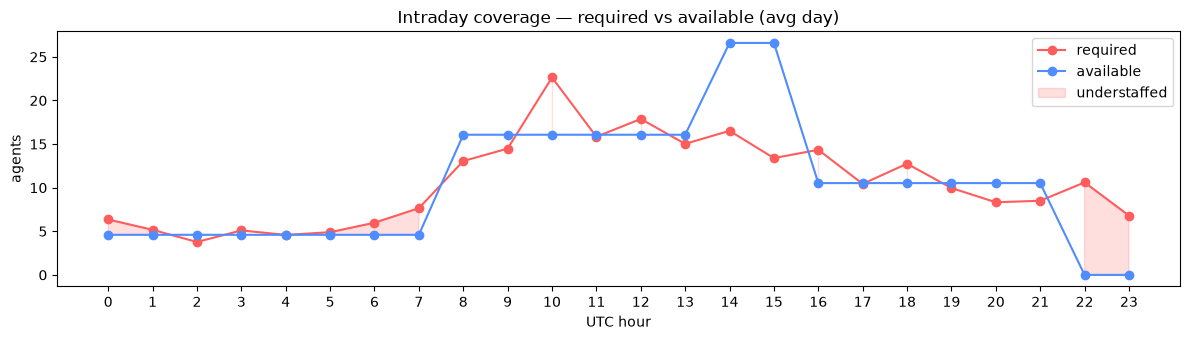

,required,available
hour,,
0,6.4,4.6
1,5.2,4.6
2,3.8,4.6
3,5.1,4.6
4,4.6,4.6
5,4.9,4.6
6,6.0,4.6
7,7.6,4.6
8,13.1,16.1


In [4]:
avg = cap.groupby('hour')[['required','available']].mean()
fig, ax = plt.subplots(figsize=(12, 3.5))
avg['required'].plot(ax=ax, marker='o', label='required', color='#ff5c5c')
avg['available'].plot(ax=ax, marker='o', label='available', color='#4f8cff')
ax.fill_between(avg.index, avg['required'], avg['available'],
                where=avg['available'] < avg['required'], color='#ff5c5c', alpha=.2, label='understaffed')
ax.set_xticks(range(24)); ax.set_xlabel('UTC hour'); ax.set_ylabel('agents')
ax.legend(); ax.set_title('Intraday coverage — required vs available (avg day)')
plt.tight_layout(); plt.show()
avg.round(1)

**Findings:** the roster is misaligned with demand — the morning peak is understaffed, the afternoon is overstaffed, and late-night async arrivals have little/no coverage.

In [5]:
under = (cap['required'] > cap['available'] + 0.5).mean() * 100
over  = (cap['available'] > cap['required'] * 1.5).mean() * 100
peak_h = avg['required'].idxmax()
print(f'{under:.0f}% of (day,hour) slots understaffed | {over:.0f}% clearly overstaffed')
print(f'demand peak = {peak_h}:00 UTC (required {avg.loc[peak_h,"required"]:.1f} vs available {avg.loc[peak_h,"available"]:.1f})')

34% of (day,hour) slots understaffed | 45% clearly overstaffed
demand peak = 10:00 UTC (required 22.6 vs available 16.1)


**Next → 03_coverage_gap:** break required vs available down **by skill/area and client**, surface gaps as a heatmap, and set up the reassignment optimizer (Step 4).